## Executive Summary

This notebook explores the modeling of daily stock excess growth rates using Hidden Markov Models (HMMs). The analysis proceeds in two main stages:
1.  A standard HMM is built from historical in-sample data.
2.  This model is then tested against well-known "stylized facts" of financial returns, revealing its strengths (capturing return distributions) and weaknesses (failing to capture volatility clustering).

To address these weaknesses, a modified HMM that incorporates price jumps is introduced and analyzed in `HMM-WithJumps-Simulation-Notebook`

 # Build a Hidden Markov Model of Daily Stock Excess Growth Rate
We are constructing an Observable Markov Model (OMM) of the excess growth rate of a ticker `XYZ` where we define the excess growth as:
$$
\begin{equation*}
R_{ij} \equiv \left(\frac{1}{\Delta{t}}\right)\cdot\ln\left(\frac{S_{i,j}}{S_{i,j-1}}\right) - \bar{r}_{f}
\end{equation*}
$$
where $R_{ij}$ denotes the excess growth rate of equity $i$ at time $j$, $\Delta{t}$ denotes the time-step between $j-1\rightarrow{j}$ (units: years), $S_{i,\star}$ denotes the share price of equity $i$ at time $\star$, and $\bar{r}_{f}$ denotes the annualized risk free rate. In this work, we build a model of daily return.

## Model
Describe the day-to-day variation of the excess growth using a fully observable Markov model $\mathcal{M}$ represented by the tuple $\mathcal{M} = (\mathcal{S},\mathcal{O},\mathbf{P},\mathbf{E})$; $\mathcal{S}$ is the set of hidden states, $\mathcal{O}$ is the set of observable states, $\mathbf{T}$ is the transition matrix, i.e., $t_{ij}\in\mathbf{T}$ is the probability of moving from hidden state $i$ to hidden state $j$ in the next time step, and $\mathbf{E}$ is the emission matrix. Because we are fully observable, the emission matrix $\mathbf{E} = \mathbf{I}$, where $\mathbf{I}$ is the identity matrix.

## Objectives
- **Task 1:** Characterize the continuous distribution of returns using MLE and MCMC, then discretize this distribution to build a Hidden Markov Model (HMM).
- **Task 2:** Simulate the standard HMM and analyze its ability to reproduce key stylized facts of financial returns, particularly volatility clustering.

## Setup
We set up the computational environment by including the `Include.jl` file. The `Include.jl` file loads external packages, various functions that we will use in the exercise, and custom types to model the components of our lab problem.
* For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/)

In [1]:
include("Include.jl");

## Constants, Data and Excess Growth

In [2]:
risk_free_rate = 0.0421; # 17-Jun-2024 10-year treasury
Δt = (1/252); # time step 1 x trading in units of years
number_of_paths = 1000; # number of potential futures should we look at
ticker = "SPY"; # This is the ticker we want to explore

### Load the training data

The training dataset for this analysis consists of daily open-high-low-close (OHLC) data for firms in the S&P 500, spanning from spanning from **January 3, 2014, to December 29, 2023** (2515 trading days). This data was cleaned and split into training and testing sets in a separate preprocessing step.

We begin by loading the pre-cleaned **training dataset** below.

In [3]:
train_dataset = MyPortfolioDataSet() |> x->x["train_dataset"]

Dict{String, DataFrame} with 424 entries:
  "EMR"  => 2515×8 DataFrame…
  "CTAS" => 2515×8 DataFrame…
  "HSIC" => 2515×8 DataFrame…
  "KIM"  => 2515×8 DataFrame…
  "PLD"  => 2515×8 DataFrame…
  "IEX"  => 2515×8 DataFrame…
  "BAC"  => 2515×8 DataFrame…
  "CBOE" => 2515×8 DataFrame…
  "EXR"  => 2515×8 DataFrame…
  "NCLH" => 2515×8 DataFrame…
  "CVS"  => 2515×8 DataFrame…
  "DRI"  => 2515×8 DataFrame…
  "DTE"  => 2515×8 DataFrame…
  "ZION" => 2515×8 DataFrame…
  "AVY"  => 2515×8 DataFrame…
  "EW"   => 2515×8 DataFrame…
  "EA"   => 2515×8 DataFrame…
  "NWSA" => 2515×8 DataFrame…
  "CAG"  => 2515×8 DataFrame…
  "GILD" => 2515×8 DataFrame…
  "FCX"  => 2515×8 DataFrame…
  "GPC"  => 2515×8 DataFrame…
  "UNP"  => 2515×8 DataFrame…
  "CDW"  => 2515×8 DataFrame…
  "SBUX" => 2515×8 DataFrame…
  ⋮      => ⋮

In [4]:
train_dataset["AAPL"]

Row,volume,volume_weighted_average_price,open,close,high,low,timestamp,number_of_transactions
,Float64,Float64,Float64,Float64,Float64,Float64,DateTime,Int64
1,3.93215e8,19.4749,19.745,19.3207,19.775,19.3011,2014-01-03T05:00:00,148584
2,4.13437e8,19.3213,19.1946,19.4261,19.5286,19.0571,2014-01-06T05:00:00,131664
3,3.17731e8,19.3329,19.44,19.2871,19.4986,19.2116,2014-01-07T05:00:00,107327
4,2.58747e8,19.4038,19.2432,19.4093,19.4843,19.2389,2014-01-08T05:00:00,86874
5,2.79621e8,19.2943,19.5286,19.1614,19.5307,19.1196,2014-01-09T05:00:00,93562
6,3.05283e8,19.0659,19.2796,19.0336,19.3143,18.9682,2014-01-10T05:00:00,113063
7,3.79443e8,19.1801,18.9254,19.1332,19.375,18.9243,2014-01-13T05:00:00,130227
8,3.34937e8,19.4033,19.2221,19.5139,19.5261,19.2021,2014-01-14T05:00:00,114856
9,3.9389e8,19.9105,19.7686,19.9057,20.0071,19.7021,2014-01-15T05:00:00,136942


In [5]:
maximum_number_trading_days = nrow(train_dataset["AAPL"])

2515

Lastly, let's get a sorted list of firms that we have in cleaned up `dataset` and save it in the `list_of_all_tickers::Array{String,1}` array

In [6]:
list_of_all_tickers = keys(train_dataset) |> collect |> x->sort(x)

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

We compute the expected (annualized) log growth rate by passing the `dataset` and the entire list of firms we have in the dataset (held in the $N\times{1}$ `list_of_all_tickers` array) to the [log_growth_matrix(...) method](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix).
* The result is stored in the `all_firms_return_matrix::Array{Float64,2}` variable, a $T-1\times{N}$ array of log return values. Each row of `all_firms_return_matrix` corresponds to a time value, while each column corresponds to a firm:

In [7]:
all_firms_excess_return_matrix = log_growth_matrix(train_dataset, list_of_all_tickers,
    Δt = Δt, risk_free_rate = risk_free_rate)

2514×424 Matrix{Float64}:
 -0.919654   6.23895   -2.91307    …  -0.797491   0.203794  -1.04737
  2.77416    1.02939    1.35029        2.09622   -0.84489    0.944368
  3.27095    0.813497  -0.036732       0.067777   1.1489    -2.62354
  0.604325  17.2178     1.65005        0.232616   3.1172    -0.410328
  1.77399    2.53751    3.27714        0.579577  -2.2108     4.36099
  0.57173   -4.00594   -0.83488    …  -0.904839  -1.95187   -3.15834
  2.81861   -0.525851   4.80363        1.7236    -1.81895   -1.1317
  2.00461    0.971404   1.86599        1.63387    4.40774   -0.179919
  1.27079    1.63203    0.0651592     -1.54918   -2.17906    1.39574
  1.17806    6.08747    0.890478      -1.57412    2.83574   -1.47836
 -0.479768   4.82799    0.96564    …  -0.363361   9.46617   -3.05083
  1.32071    3.57107   -2.38986        0.668513   4.48013    0.298431
 -4.78114    1.34375   -3.05834       -2.19455   -6.69117    1.36402
  ⋮                                ⋱                        
  6.83722   -

Extract the growth rate for your `ticker::String` of interest, and save this in the `Rᵢ::Array{Float64,1}` array. This is the observed _in-sample_ data.

In [8]:
Rᵢ = findfirst(x->x==ticker, list_of_all_tickers) |> i-> all_firms_excess_return_matrix[:,i]

2514-element Vector{Float64}:
 -0.6266399670984476
  0.8405262386945092
  0.16389199696256232
 -0.010233691939436122
  0.25823420862761537
 -1.378088774125505
  0.32241271641711466
  2.0009590819913137
 -0.322149763808254
 -0.43598073791618397
 -0.07579593758943923
  0.3992882778085264
 -1.99925091651247
  ⋮
  2.473645326630101
  2.1846892155556126
 -1.3071088568715163
  1.300092524780104
  1.0882119750549104
 -1.2691490306414208
 -0.2817789495022863
  1.3302918641120702
  0.6544841382666371
  0.307245721134233
  0.48928417021417847
 -0.7889919650587696

## Task 1: Characterizing and Discretizing the Return Distribution
### Methodology: Building the Model from Data

To construct the HMM, we first need to define its components from the historical returns data (`Rᵢ`):

1.  **States:** The continuous range of daily returns is discretized into a finite number of states. Each state represents a specific market condition, from significant losses (State 1) to significant gains (State N). We define these states by calculating the quantiles of the historical return distribution.

2.  **Transition Matrix:** The probability of moving from one state to another on the next day is estimated by observing the frequency of these transitions in the historical data.

3.  **Emission Probabilities:** In this model, the emissions are deterministic. Being in a certain state means the return is within the predefined quantile range for that state.

First, consider the states $\mathcal{S}$. Suppose we number the excess return values, ranging from `super bad = 1,` $\dots$,` unchanged,` $\dots$,` super good = N,` where if $R\ll{0}$, then we are in the `super bad = 1,` state or $R\gg{0}$ we are in the `super good = N` state (or we are someplace in between).
* __Idea__: Use the [cumulative distribution function](https://en.wikipedia.org/wiki/Cumulative_distribution_function) computed from the observed return series $R_{i,1}, \dots, R_{i,n}$ to partition the actual (historical) excess returns into one of a fixed number of categories. Once we have the categories, compute the probability that category $i$ on the day $k$ is followed by category $j$ on the day $k+1$. These values are entries in the state transition matrix $\hat{\mathbf{T}}$.
* To start, specify a value for the  `number_of_states` variable, where the `number_of_states` controls how many categories we are using when splitting up the excess return time series. We then set the `states` vector, which holds the states (numbered from `1`$\rightarrow$`number_of_states`).

In [9]:
number_of_states = 60; # specify a value here, too many states or too little states would impact the model performance. 80 should provide somewhat fair granuality 
states = range(1,stop=number_of_states) |> collect;

Next, we set up the emissions matrix $\mathbf{E}$. For this example, because the states are __fully observable__, i.e., we can see the states directly,  the emission matrix $\mathbf{E}$ is the identity matrix $\mathbf{I}$:

In [10]:
E = diagm(ones(number_of_states))

60×60 Matrix{Float64}:
 1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

### Estimate the transition matrix $\hat{\mathbf{T}}$ from market data
To estimate the transition matrix $\hat{\mathbf{T}}$, we'll estimate the transition probabilities from the excess return data calculated in the `Prerequisites` section and saved in the `Rᵢ` variable.

In [11]:
in_sample_dataset = Rᵢ[1:(maximum_number_trading_days-1)] # set of excess return

2514-element Vector{Float64}:
 -0.6266399670984476
  0.8405262386945092
  0.16389199696256232
 -0.010233691939436122
  0.25823420862761537
 -1.378088774125505
  0.32241271641711466
  2.0009590819913137
 -0.322149763808254
 -0.43598073791618397
 -0.07579593758943923
  0.3992882778085264
 -1.99925091651247
  ⋮
  2.473645326630101
  2.1846892155556126
 -1.3071088568715163
  1.300092524780104
  1.0882119750549104
 -1.2691490306414208
 -0.2817789495022863
  1.3302918641120702
  0.6544841382666371
  0.307245721134233
  0.48928417021417847
 -0.7889919650587696

###  Analyzing the Underlying Continuous Distribution

Before building our discrete-state HMM, we first seek to understand the underlying continuous probability distribution of the daily excess returns. A key part of modeling is choosing a distribution that accurately captures the stylized facts of the data, such as **"fat tails"** (a higher probability of extreme events than a normal distribution would suggest).

In this section, we will:
1.  Compare two candidate distributions: the **Laplace distribution** and the **Student's t-distribution**.
2.  Compare two different methodologies for fitting these distributions: **Maximum Likelihood Estimation (MLE)** and the more robust **Markov Chain Monte Carlo (MCMC)**.

First, we use our generic MCMC function to fit a **Student's t-distribution** to the return data. This is our primary candidate for a model that can capture fat tails. The output will be a `chain` object containing the full posterior distributions for the model's parameters: mean (`μ`), volatility (`σ`), and degrees-of-freedom (`ν`).

┌ Info: Found initial step size
└   ϵ = 0.05
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:02


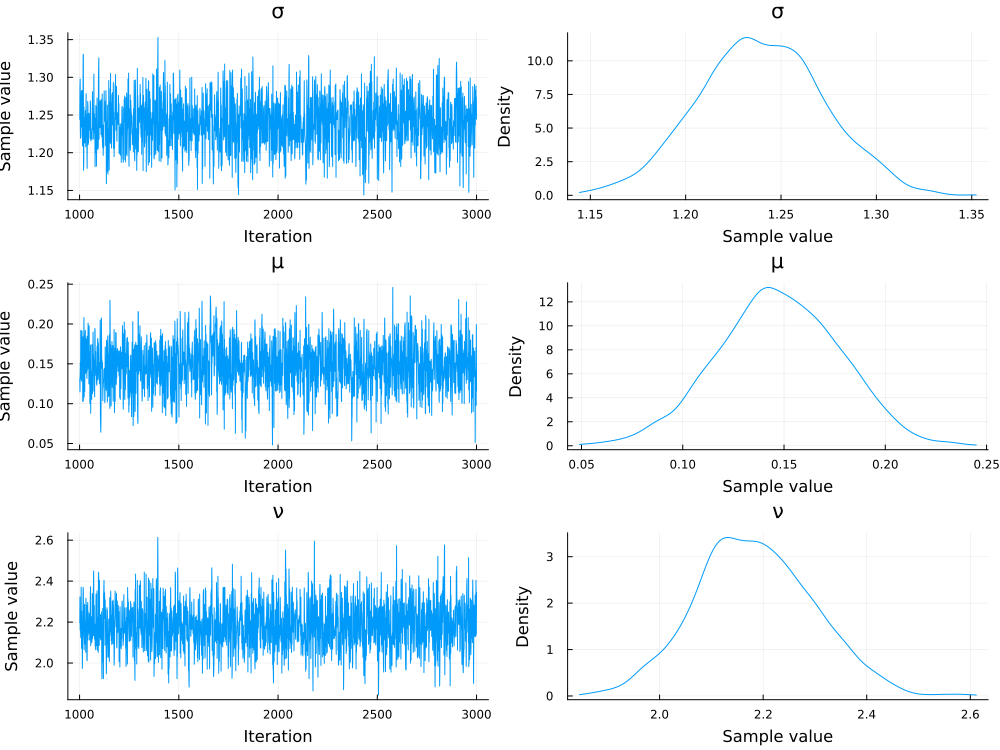

In [12]:
# To learn the Student's t-distribution:
chain_t = learn_distribution_mcmc(StudentTModel(), Rᵢ);

# You can now analyze chain_t and chain_laplace as before
plot(chain_t)


Next, for a direct comparison, we fit the **Laplace distribution** using the same MCMC methodology. This will produce a `chain` object containing posteriors for the Laplace parameters: mean (`μ`) and scale (`b`).

┌ Info: Found initial step size
└   ϵ = 0.025
Sampling: 100%|█████████████████████████████████████████| Time: 0:00:00


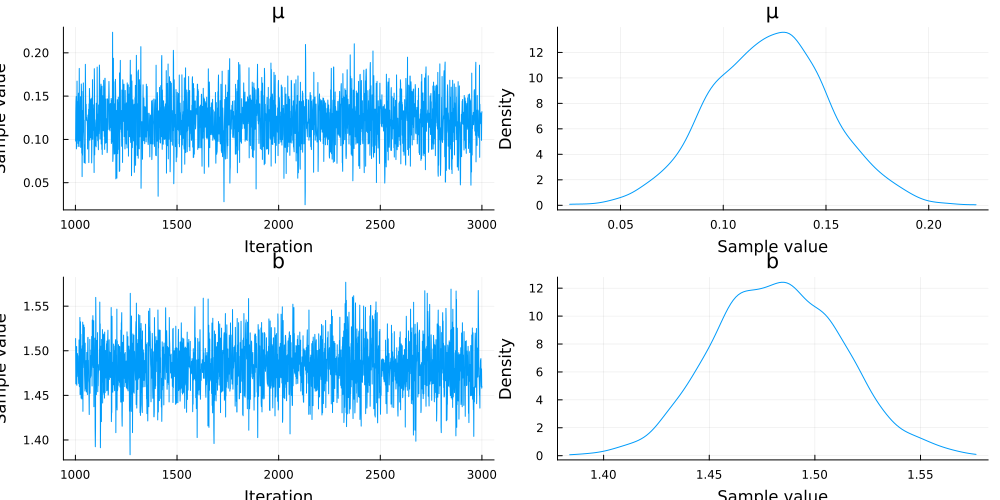

In [13]:
# To learn the Laplace distribution:
chain_laplace = learn_distribution_mcmc(LaplaceModel(), Rᵢ);

plot(chain_laplace)


Finally, we will prepare all of our fitted models for a head-to-head comparison. We will use the traditional **Maximum Likelihood Estimation (MLE)** to fit a Laplace distribution as a baseline. Then, we will bring together all the models—both MCMC and MLE—for a final comparison using visual plots and quantitative statistics.

In [14]:
# --- Prepare All Four Models ---

# 1. MLE Model
Laplace_MLE = fit_mle(Laplace, Rᵢ);

# 2. MCMC Models 
μ_t_mean = mean(chain_t[:μ])
σ_t_mean = mean(chain_t[:σ])
ν_t_mean = mean(chain_t[:ν])
StudentT_MCMC = LocationScale(μ_t_mean, σ_t_mean, TDist(ν_t_mean))

μ_laplace_mean = mean(chain_laplace[:μ])
b_laplace_mean = mean(chain_laplace[:b])
Laplace_MCMC = Laplace(μ_laplace_mean, b_laplace_mean);


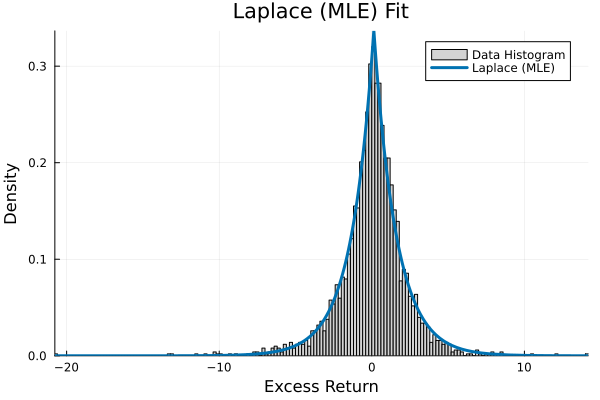

In [15]:
# --- Plot 1: Laplace (MLE) vs. Data ---

# Create a histogram of the actual returns data
histogram(Rᵢ, normalize=:pdf, bins=200, label="Data Histogram", c=:lightgray)

# Plot the Laplace (MLE) distribution
plot!(x -> pdf(Laplace_MLE, x), lw=3, label="Laplace (MLE)", c="#0072B2") # Blue

title!("Laplace (MLE) Fit")
xlabel!("Excess Return")
ylabel!("Density")
xlims!(extrema(Rᵢ))

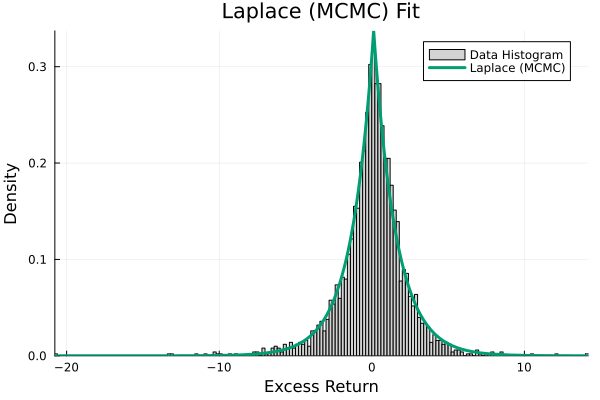

In [16]:
# --- Plot 3: Laplace (MCMC) vs. Data ---

# Create a histogram of the actual returns data
histogram(Rᵢ, normalize=:pdf, bins=200, label="Data Histogram", c=:lightgray)

# Plot the Laplace (MCMC) distribution
plot!(x -> pdf(Laplace_MCMC, x), lw=3, label="Laplace (MCMC)", c="#009E73") # Bluish Green

title!("Laplace (MCMC) Fit")
xlabel!("Excess Return")
ylabel!("Density")
xlims!(extrema(Rᵢ))

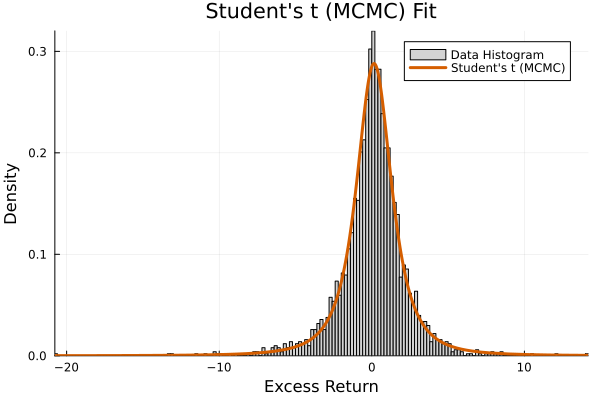

In [17]:
# --- Plot 2: Student's t (MCMC) vs. Data ---

# Create a histogram of the actual returns data
histogram(Rᵢ, normalize=:pdf, bins=200, label="Data Histogram", c=:lightgray)

# Plot the Student's t (MCMC) distribution
plot!(x -> pdf(StudentT_MCMC, x), lw=3, label="Student's t (MCMC)", c="#D55E00") # Vermillion/Orange

title!("Student's t (MCMC) Fit")
xlabel!("Excess Return")
ylabel!("Density")
xlims!(extrema(Rᵢ))

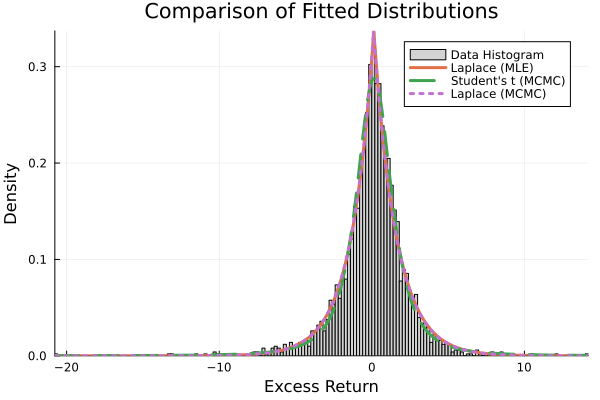

In [18]:
# ---  Visual Comparison of Four Distributions ---

# Create a histogram of the actual returns data
histogram(Rᵢ, normalize=:pdf, bins=200, label="Data Histogram", c=:lightgray)

# Plot the four models
plot!(x -> pdf(Laplace_MLE, x), lw=3, label="Laplace (MLE)")
plot!(x -> pdf(StudentT_MCMC, x), lw=3, label="Student's t (MCMC)", ls=:dash)
plot!(x -> pdf(Laplace_MCMC, x), lw=3, label="Laplace (MCMC)", ls=:dot)

title!("Comparison of Fitted Distributions")
xlabel!("Excess Return")
ylabel!("Density")
xlims!(extrema(Rᵢ))

In [19]:
# --- UPDATED: Quantitative Comparison of Four Distributions ---

# A. Summary Statistics
println("--- Summary Statistics ---")
println("Laplace (MLE):")
println("  Mean:      ", mean(Laplace_MLE))
println("  Variance:  ", var(Laplace_MLE))
println("  Kurtosis:  ", kurtosis(Laplace_MLE))

println("\nStudent's t (MCMC):")
println("  Mean:      ", mean(StudentT_MCMC))
println("  Variance:  ", var(StudentT_MCMC))
println("  Kurtosis:  ", kurtosis(StudentT_MCMC))

println("\nLaplace (MCMC):")
println("  Mean:      ", mean(Laplace_MCMC))
println("  Variance:  ", var(Laplace_MCMC))
println("  Kurtosis:  ", kurtosis(Laplace_MCMC))


# B. AIC Comparison (Lower is Better)
log_like_L_MLE = loglikelihood(Laplace_MLE, Rᵢ)
log_like_T_MCMC = loglikelihood(StudentT_MCMC, Rᵢ)
log_like_L_MCMC = loglikelihood(Laplace_MCMC, Rᵢ)

aic_L_MLE = 2*2 - 2*log_like_L_MLE
aic_T_MCMC = 2*3 - 2*log_like_T_MCMC
aic_L_MCMC = 2*2 - 2*log_like_L_MCMC

println("\n--- Model Comparison (Lower AIC is Better) ---")
println("AIC for Laplace (MLE):       ", aic_L_MLE)
println("AIC for Laplace (MCMC):      ", aic_L_MCMC)
println("AIC for Student's t (MCMC):  ", aic_T_MCMC)

--- Summary Statistics ---
Laplace (MLE):
  Mean:      0.13330821717648392
  Variance:  4.396511193895789
  Kurtosis:  3.0

Student's t (MCMC):
  Mean:      0.1471058438493156
  Variance:  18.229911675327443
  Kurtosis:  Inf

Laplace (MCMC):
  Mean:      0.12251188963168862
  Variance:  4.394372460984389
  Kurtosis:  3.0

--- Model Comparison (Lower AIC is Better) ---
AIC for Laplace (MLE):       10497.331660166179
AIC for Laplace (MCMC):      10497.51641913868
AIC for Student's t (MCMC):  10514.36331656149


In [20]:
# Choose one of these to be your distribution in the variable d that will be used for generating CDF
d = Laplace_MLE;  # StudentT_MCMC or Laplace_MCMC or Laplace_MLE

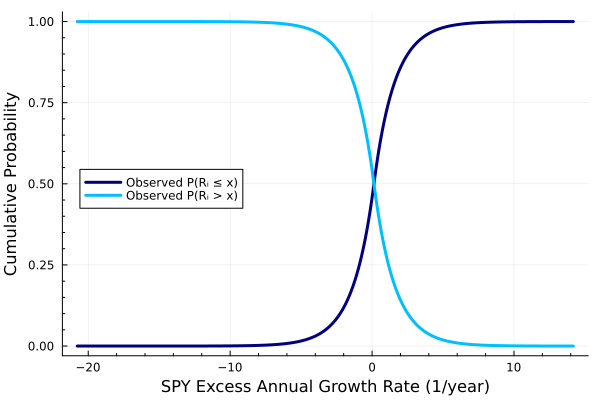

In [21]:
let

    # regions of return -
    number_of_samples = 1000;
    minimum_obs_growth = minimum(in_sample_dataset);
    maximum_obs_growth = maximum(in_sample_dataset);
    RA = range(minimum_obs_growth,stop = maximum_obs_growth, length = number_of_samples) |> collect;

    X = Array{Float64,2}(undef, number_of_samples,2);
    for i ∈ eachindex(RA)

        X[i,1] = RA[i];
        X[i,2] = cdf(d, RA[i]);
    end

    plot(X[:,1], X[:,2], lw=3, c=:navy, label="Observed P(Rᵢ ≤ x)", xminorticks=5, yminorticks=5)
    plot!(X[:,1], 1 .- X[:,2], lw=3, c=:deepskyblue1, label="Observed P(Rᵢ > x)", legend=:left)

    xlabel!("$(ticker) Excess Annual Growth Rate (1/year)", fontsize=18);
    ylabel!("Cumulative Probability", fontsize=18);
end
     # savefig(joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-$(number_of_states)-ExcessGrowthRate-Cumulative-Probability.pdf"))

Next, we generate the percentile cutoffs that we use to establish the bounds that correspond to each category of return, i.e., `super bad` or `super good`, etc.

In [22]:
percentage_cutoff = range(0.0,stop=1.0,length=(number_of_states+1)) |> collect

61-element Vector{Float64}:
 0.0
 0.016666666666666666
 0.03333333333333333
 0.05
 0.06666666666666667
 0.08333333333333333
 0.1
 0.11666666666666667
 0.13333333333333333
 0.15
 0.16666666666666666
 0.18333333333333332
 0.2
 ⋮
 0.8166666666666667
 0.8333333333333334
 0.85
 0.8666666666666667
 0.8833333333333333
 0.9
 0.9166666666666666
 0.9333333333333333
 0.95
 0.9666666666666667
 0.9833333333333333
 1.0

Now that we have the cutoffs, compute the lower and upper bound for each potentiual category. To do this, we'll use the [quantile function](https://juliastats.org/Distributions.jl/stable/univariate/#Statistics.quantile-Tuple{UnivariateDistribution,%20Real}) exported by the [Distributions.jl package](https://github.com/JuliaStats/Distributions.jl). For a given `0 ≤ q ≤ 1`, `quantile(d, q)` is the smallest value `x`
for which `cdf(d, x) ≥ q`.

In [23]:
bounds = Array{Float64,2}(undef, number_of_states, 3)
for s ∈ states
    bounds[s,1] = quantile(d,percentage_cutoff[s])
    bounds[s,2] = quantile(d,percentage_cutoff[s+1])
    bounds[s,3] = s
end
bounds

60×3 Matrix{Float64}:
 -Inf       -4.90948   1.0
  -4.90948  -3.88179   2.0
  -3.88179  -3.28062   3.0
  -3.28062  -2.85409   4.0
  -2.85409  -2.52325   5.0
  -2.52325  -2.25293   6.0
  -2.25293  -2.02438   7.0
  -2.02438  -1.8264    8.0
  -1.8264   -1.65176   9.0
  -1.65176  -1.49555  10.0
  -1.49555  -1.35424  11.0
  -1.35424  -1.22523  12.0
  -1.22523  -1.10656  13.0
   ⋮                  
   1.49185   1.62086  49.0
   1.62086   1.76217  50.0
   1.76217   1.91838  51.0
   1.91838   2.09301  52.0
   2.09301   2.29099  53.0
   2.29099   2.51954  54.0
   2.51954   2.78986  55.0
   2.78986   3.12071  56.0
   3.12071   3.54724  57.0
   3.54724   4.1484   58.0
   4.1484    5.1761   59.0
   5.1761   Inf       60.0

Now that we have the category bounds, let's take the excess return data and determine which state an excess return observation corresponds to. For each sample in the `in_sample_dataset`:
* Classify the sample value into one of the possible categories. Let `state = 1` equal the worst return, and `state = number_of_states` equal the best return. Save these results in the `encoded_in_sample` array:

In [24]:
encoded_in_sample = Array{Int64,1}();
for i ∈ eachindex(in_sample_dataset)
    value = in_sample_dataset[i];

    class_index = 1;
    for s ∈ states
        if (bounds[s,1] ≤ value && value < bounds[s,2])
            class_index = s;
            break;
        end
    end
    push!(encoded_in_sample, class_index);
end
encoded_in_sample

2514-element Vector{Int64}:
 18
 42
 31
 28
 33
 11
 34
 52
 23
 21
 27
 35
  8
  ⋮
 54
 53
 12
 47
 45
 12
 23
 47
 39
 34
 37
 17

This cell can be used to check the most frequent hidden state.

In [25]:
counts = countmap(encoded_in_sample) |> argmax;

In the matrix $\mathbf{T}$ compute the `counts` for transition from state `i` to state `j`:

In [26]:
T = zeros(number_of_states, number_of_states)
number_insample = length(encoded_in_sample);
for i ∈ 2:number_insample
    start_index = encoded_in_sample[i-1];
    stop_index = encoded_in_sample[i];
    T[start_index,stop_index] += 1;
end
T

60×60 Matrix{Float64}:
 10.0  6.0  2.0  4.0  0.0  1.0  1.0  …  2.0  0.0  3.0  1.0  3.0  0.0  2.0
  3.0  2.0  2.0  0.0  3.0  0.0  2.0     1.0  0.0  0.0  1.0  1.0  1.0  2.0
  3.0  3.0  0.0  1.0  3.0  2.0  1.0     0.0  0.0  2.0  1.0  0.0  1.0  2.0
  4.0  1.0  2.0  0.0  1.0  1.0  1.0     1.0  1.0  1.0  2.0  0.0  0.0  1.0
  2.0  2.0  2.0  3.0  2.0  1.0  2.0     1.0  2.0  0.0  0.0  1.0  0.0  0.0
  2.0  2.0  1.0  1.0  1.0  1.0  1.0  …  0.0  1.0  1.0  1.0  1.0  0.0  0.0
  1.0  0.0  1.0  0.0  1.0  0.0  0.0     2.0  0.0  0.0  0.0  2.0  2.0  1.0
  3.0  1.0  3.0  3.0  0.0  0.0  1.0     2.0  1.0  0.0  2.0  3.0  0.0  0.0
  5.0  0.0  1.0  0.0  1.0  0.0  3.0     0.0  4.0  1.0  1.0  3.0  0.0  0.0
  1.0  2.0  1.0  0.0  1.0  0.0  0.0     2.0  2.0  1.0  0.0  0.0  0.0  1.0
  0.0  0.0  2.0  0.0  0.0  2.0  3.0  …  0.0  1.0  3.0  1.0  0.0  0.0  0.0
  0.0  0.0  1.0  1.0  3.0  2.0  1.0     1.0  1.0  2.0  0.0  0.0  0.0  0.0
  1.0  1.0  0.0  0.0  2.0  1.0  0.0     0.0  0.0  2.0  1.0  2.0  0.0  0.0
  ⋮            

From the `counts` matrix $\mathbf{T}$, compute the transtion probability matrix $\hat{\mathbf{T}}$:

In [27]:
T̂ = zeros(number_of_states, number_of_states)
for row ∈ states
    Z = sum(T[row,:]);
    for col ∈ states
        T̂[row,col] = (1/Z)*T[row,col]
    end
end
T̂

60×60 Matrix{Float64}:
 0.163934   0.0983607  0.0327869  …  0.0491803  0.0        0.0327869
 0.075      0.05       0.05          0.025      0.025      0.05
 0.0714286  0.0714286  0.0           0.0        0.0238095  0.047619
 0.117647   0.0294118  0.0588235     0.0        0.0        0.0294118
 0.0444444  0.0444444  0.0444444     0.0222222  0.0        0.0
 0.05       0.05       0.025      …  0.025      0.0        0.0
 0.0263158  0.0        0.0263158     0.0526316  0.0526316  0.0263158
 0.0769231  0.025641   0.0769231     0.0769231  0.0        0.0
 0.131579   0.0        0.0263158     0.0789474  0.0        0.0
 0.0294118  0.0588235  0.0294118     0.0        0.0        0.0294118
 0.0        0.0        0.0454545  …  0.0        0.0        0.0
 0.0        0.0        0.025641      0.0        0.0        0.0
 0.0238095  0.0238095  0.0           0.047619   0.0        0.0
 ⋮                                ⋱                        
 0.0        0.0217391  0.0           0.0217391  0.0217391  0.0
 0.02

### Generate the stationary distribution from the estimated $\hat{\mathbf{T}}$ matrix
Generate the stationary distribution for the estimated transition matrix $\hat{\mathbf{T}}$ and use it to construct a [Categorical distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Categorical) representing the stationary distrubution, save the [Categorical distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Categorical) in the `π̄`-variable:

In [28]:
power_value = 50;
π̄ = (T̂^power_value) |> tmp -> Categorical(tmp[1,:]); # compute the stationary distribution (approx value is ok)

## Task 2: In-Sample Analysis of the Standard HMM
To do the simulation, we first build a [`MyHiddenMarkovModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/markov/#VLQuantitativeFinancePackage.MyHiddenMarkovModel), which holds the data for our Markov model. We use a [`build(...)` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/markov/#VLQuantitativeFinancePackage.build-Tuple{Type{MyHiddenMarkovModel},%20NamedTuple}), which takes information about the `states,` the estimated transition matrix $\hat{\mathbf{T}}$, and the emission matrix $\mathbf{E}$ and returns a [`MyHiddenMarkovModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/markov/#VLQuantitativeFinancePackage.MyHiddenMarkovModel), which we save in the `model` variable.

In [29]:
model = build(MyHiddenMarkovModel, (
    states = states,
    T = T̂,
    E = E
));

### Implement the `MARKOV-SIMULATION` to generate hypothetical state sequences
Generate 'number_of_paths' example sequences, each containing 'number_of_steps' days. These variables determine the length and number of our hypothetical return sequences. Assume each path starts from a draw from the stationary distribution `π̄.`
* Save the simulated return sequences in the `archive::Array{Int64,2}(undef, number_of_steps, number_of_paths)` array, where the `row` index corresponds to a path, and the `col` index corresponds to a day.
* We have implemented some shortcut logic to speed up the implementation. To evaluate the Markov model for a `number_of_steps,` issue the command `model(start_state, number_of_steps).` This will compute a chain with `number_of_steps` starting as `start_state` and return the simulated sequence as an `array.`

In [30]:
number_of_steps = maximum_number_trading_days-1;
encoded_archive = Array{Int64,2}(undef, number_of_steps, number_of_paths);
for i ∈ 1:number_of_paths
    start_state = rand(π̄);
    tmp = model(start_state, number_of_steps)
    for j ∈ 1:number_of_steps
        encoded_archive[j,i] = tmp[j]
    end
end
encoded_archive

2514×1000 Matrix{Int64}:
  6  58  29  19  47  52  53  40  50  …  52  48  54  34  41  46  22  55  58
  5  54  52   2  12  47  24  58   5     56  57  52  23  31  25   5  54  35
  3   2  47   2  25  54  45  58   1     41  40  43  20  32  42   6   6  18
  1  21  30   5   9  20  46  42   4     23  56  18   7  24  41   4   4  17
 25  27  15  18  55  59  15  46  11     21  33  48   1  13  39  15   3  45
 19   8  50  42  51  13  15  29  29  …  22  52  51  54   1  25  50  56  28
 18   4   4  42  46  25  46  11  21     39  47  56  56   4  21  38  51  14
 17  10  53  24  40  40  45  32  51     36  54  17  48  15   5  29  44  36
 24   9   3  39  25   9  48  15  35     36  59  14  24  51   6  14  53  31
 46  41   6  35  31   1  25  53  15     50  10  31   2   9  36  10  35  17
 11  12  58   6  29   4  31  18  15  …  38  54  17  49  30  23  54  54  15
  7   3  59  55  12  55  21  46  18     56   4  47  54  25  27  51  58  10
 53   5  58  55  51  60  50  11  41     20   1  21  24  37   3  19  51  54


### Decode operation
To turn the state $s\in\mathcal{S}$ back into an excess return value, we need to __decode__ the state. To do this, let's construct a [Normal distribution](https://en.wikipedia.org/wiki/Normal_distribution) describing the observed return values associated with each state in the `encoded_in_sample` dataset.
* We collect the observed excess return samples associated with a particular state $s$, store them in a `tmp` array, and use [Maximum Likelihood Estimation](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation) to estimate a [Normal distribution exported from the Distributions.jl package](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Normal)

In [31]:
decode_distribution_model = Dict{Int,Normal}()
for s ∈ states

    # what indexes correspond to state s
    index_collection_state_s = findall(x-> x == s, encoded_in_sample);
    tmp = Array{Float64,1}();
    for i ∈ index_collection_state_s
        decoded_value = Rᵢ[i];
        push!(tmp, decoded_value);
    end
    decode_distribution_model[s] = fit_mle(Normal,tmp);
end
decode_distribution_model;

Then, generate a random value for the excess return by sampling the appropriate [Normal distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Normal). We develop `number_of_paths` trajectories, each containing `number_of_steps` values. We store these values in the `decoded_archive` variable:

In [32]:
in_sample_decoded_archive = Array{Float64,2}(undef, number_of_steps, number_of_paths);
for i ∈ 1:number_of_paths
    for j ∈ 1:number_of_steps
        s = encoded_archive[j,i];
        in_sample_decoded_archive[j,i] =  decode_distribution_model[s] |> d -> rand(d)
    end
end
in_sample_decoded_archive # actual excess growth value

2514×1000 Matrix{Float64}:
 -2.40904    4.0036      0.018179   …  -0.360343    2.70491    4.03149
 -2.60991    2.33424     1.96198       -2.71071     2.42985    0.376933
 -3.60924   -4.89565     1.29414       -2.38232    -2.29613   -0.70301
 -8.75899   -0.458273    0.0993678     -3.07695    -3.03103   -0.792154
 -0.159405  -0.0249475  -0.905026      -0.9515     -3.72125    1.11996
 -0.577615  -1.83552     1.65704    …   1.70251     2.87169    0.0285687
 -0.675381  -2.83187    -3.08204        0.583483    1.88387   -1.06492
 -0.752871  -1.63068     2.25388        0.0418926   1.00092    0.441818
 -0.1954    -1.73249    -3.46199       -1.08019     2.2232     0.145758
  1.16636    0.761982   -2.41586       -1.61441     0.372261  -0.766822
 -1.41159   -1.31156     3.65834    …   2.29366     2.49122   -0.959151
 -2.1614    -3.76677     4.66782        1.8345      3.43438   -1.52866
  2.12472   -2.6971      4.01998       -0.616055    1.85069    2.32776
  ⋮                                 ⋱     

### Visualize an example in-sample return trajectory
`Unhide` the code block to see how we plotted the observed (red) and simulated (blue) excess growth rate values for a randomly selected sample model generated sample path.

`Unhide` the code block below to see how we plotted the observed and simulated excess annual growth rate distribution for the in-sample data.

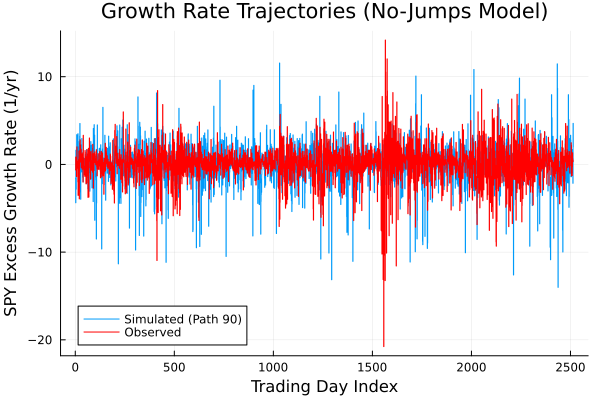

"/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps/figs/Fig-SPY-60-InSample-Return-Trajectories-NJ.pdf"

In [33]:
let
    # Select a random path to plot, just like in your working example
    index_to_plot = rand(1:number_of_paths)

    # Plot the SIMULATED data first, creating the plot
    q = plot(in_sample_decoded_archive[:, index_to_plot], linetype=:steppost, label="Simulated (Path $(index_to_plot))")

    # Add the OBSERVED data to the plot, slicing it to match the simulation length
    plot!(in_sample_dataset[1:(number_of_steps - 1)], linetype=:steppost, c=:red, label="Observed")
    
    # Add labels and a title
    xlabel!("Trading Day Index")
    ylabel!("$(ticker) Excess Growth Rate (1/yr)")
    title!("Growth Rate Trajectories (No-Jumps Model)")

    display(q)
end
 savefig(joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-$(number_of_states)-InSample-Return-Trajectories-NJ.pdf"))

### Check: Are the Simulated and observed in-sample distributions the same?
If our HMM is correct, then the observed excess growth rate distribution and the excess growth distribution calculated by our model should look like they are drawn from the same distribution.


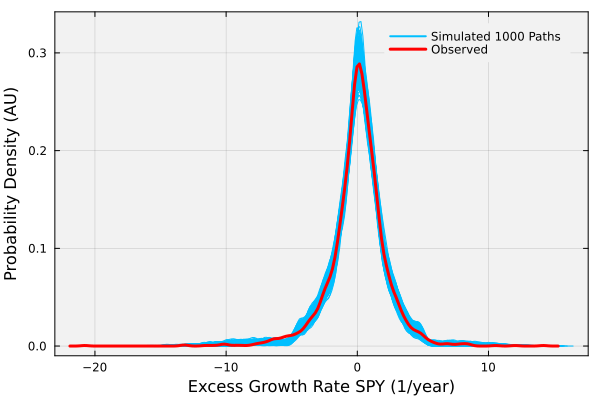

"/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps/figs/Fig-SPY-60-InSample-Density-Comparison-NJ.pdf"

In [34]:
let
    q = plot();
    density!(in_sample_decoded_archive[:,1], lw=2, c=:deepskyblue1, label="Simulated $(number_of_paths) Paths ",
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    for i ∈ 2:number_of_paths
        density!(in_sample_decoded_archive[:,i], lw=1, c=:deepskyblue1, label="")
    end
    density!(in_sample_dataset, c=:red, lw=3, label="Observed")
    xlabel!("Excess Growth Rate $(ticker) (1/year)", fontsize=18)
    ylabel!("Probability Density (AU)", fontsize=18)
    current()

    display(q)
end
savefig(joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-$(number_of_states)-InSample-Density-Comparison-NJ.pdf"))

#### Kolmogorov-Smirnov (K-S) Test

The Kolmogorov-Smirnov (K-S) test is a non-parametric method used to determine if two samples of data are drawn from the same underlying distribution. It works by quantifying the **maximum vertical distance** between the empirical cumulative distribution functions (ECDFs) of the two samples.

The hypotheses are:
- **H0 (null hypothesis):** The two samples are drawn from the same distribution.
- **H1 (alternative hypothesis):** The two samples are drawn from different distributions.

The K-S test is generally most sensitive to differences in the **center (i.e., around the median)** of the distributions.

To check this hypothesis, we will use [the `ApproximateTwoSampleKSTest` function from the `HypothesisTests.jl` package](https://github.com/JuliaStats/HypothesisTests.jl). Let's run it on a single (randomly selected) example trajectory to see what happens (most of the time, we fail to reject `H0`, i.e., the test suggests the samples are from the same distribution):

In [35]:
ApproximateTwoSampleKSTest(in_sample_dataset,in_sample_decoded_archive[:,rand(1:number_of_paths)])

Approximate two sample Kolmogorov-Smirnov test
----------------------------------------------
Population details:
    parameter of interest:   Supremum of CDF differences
    value under h_0:         0.0
    point estimate:          0.0107399

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.9987

Details:
    number of observations:   [2514,2514]
    KS-statistic:              0.3807729859453996


However, we have `number_of_paths` example trajectories (not just one), so let's do the same test on each sample and compute an overall expected score. Specify a `pvalue_cutoff` value to check against. If the test returns `pvalue > pvalue_cutoff,` then we fail to reject `H0:null hypothesis`, i.e., `x` and `y` appear to be drawn from the same distribution.

In [36]:
let
    pvalue_cutoff = 0.05; # cutoff
    pass_counter = 0;
    for i ∈ 1:number_of_paths
        test_value = ApproximateTwoSampleKSTest(in_sample_dataset,in_sample_decoded_archive[:,i]) |> pvalue
        if (test_value > pvalue_cutoff)
            pass_counter += 1 # we pass (fail to reject) x and y are from the same distribution
        end
    end
    println("Pass percentage: $((pass_counter/number_of_paths)*100)%")
end

Pass percentage: 99.2%


#### Anderson-Darling Test
The Anderson-Darling test is another method for testing whether two samples of data come from the same distribution. A key advantage of the A-D test over the K-S test is its higher sensitivity to differences in the tails of the distributions. This is particularly relevant for financial time series, where capturing tail risk and extreme events is critical.
Let's run it on a single (randomly selected) example trajectory to see what happens (most of the time, we fail to reject `H0`, i.e., the test suggests the samples are from the same distribution):

In [37]:
KSampleADTest(in_sample_dataset,in_sample_decoded_archive[:,rand(1:number_of_paths)])

k-sample Anderson-Darling test
------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: fail to reject h_0
    one-sided p-value:           0.9164

Details:
    number of samples:        2
    number of observations:   5028
    SD of A²k:                0.7611095325190996
    A²k statistic:            0.3265050790690832
    standardized statistic:   -0.884885673027641
    modified test:            true
    p-value calculation:      asymptotic


However, we have `number_of_paths` example trajectories (not just one), so let's do the same test on each sample and compute an overall expected score. Specify a `pvalue_cutoff` value to check against. If the test returns `pvalue > pvalue_cutoff,` then we fail to reject `H0:null hypothesis`, i.e., `x` and `y` appear to be drawn from the same distribution.

In [38]:
let
    pvalue_cutoff = 0.05; # cutoff
    pass_counter = 0;
    for i ∈ 1:number_of_paths
        test_value = KSampleADTest(in_sample_dataset,in_sample_decoded_archive[:,i]) |> pvalue
        if (test_value > pvalue_cutoff)
            pass_counter += 1 # we pass (fail to reject) x and y are from the same distribution
        end
    end
    println("Pass percentage: $((pass_counter/number_of_paths)*100)%")
end

Pass percentage: 98.8%


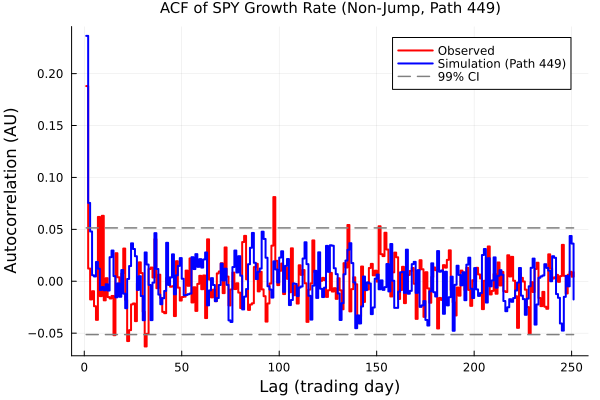

"/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps/figs/Fig-SPY-60-ACF-Growth-NJ.pdf"

In [39]:
let
    random_index = rand(1:number_of_paths)
    simulated_path = in_sample_decoded_archive[:, random_index]
    q = plot_acf_comparison(Rᵢ, simulated_path, "ACF of $(ticker) Growth Rate (Non-Jump, Path $(random_index))", random_index)
    display(q)
end
savefig(joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-$(number_of_states)-ACF-Growth-NJ.pdf"))

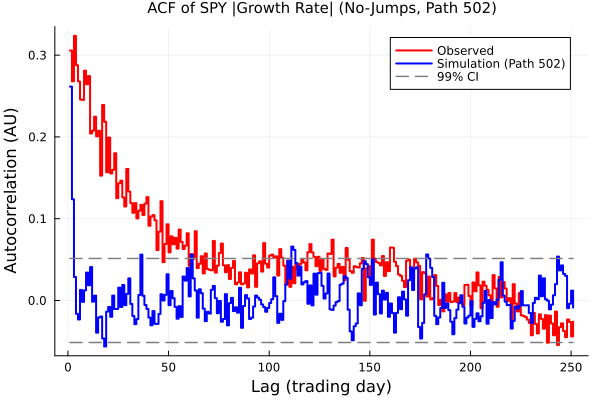

"/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps/figs/Fig-SPY-60-ACF-Absolute-Growth-NJ.pdf"

In [40]:
let
    random_index = rand(1:number_of_paths)
    simulated_path = in_sample_decoded_archive[:, random_index]
    q = plot_acf_comparison(Rᵢ, simulated_path, "ACF of $(ticker) |Growth Rate| (No-Jumps, Path $(random_index))", random_index, is_absolute=true)

    display(q)
    
end
savefig(joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-$(number_of_states)-ACF-Absolute-Growth-NJ.pdf"))

### Conclusion from the Non-Jump Model Analysis

The autocorrelation plots reveal a key insight:
* **Success:** The standard HMM successfully replicates the lack of significant autocorrelation in raw returns, consistent with the efficient market hypothesis.
* **Failure:** The model completely fails to reproduce the strong, persistent autocorrelation in **absolute returns**. This means the simple HMM **cannot capture volatility clustering**, a critical stylized fact of financial markets.

This failure motivates the need for a more sophisticated model, which we explore in `HMM-WithJumps-Simulation-Notebook`.

### Disclaimer: For Educational and Research Purposes Only

The content in this repository is provided strictly for informational, educational, and research purposes. It is not intended as, and should not be construed as, financial advice, an offer, or a solicitation to buy or sell any securities or derivative products.

#### Risk Warning

Trading and investing involve substantial risk. The models and strategies demonstrated here are for illustrative purposes only. Past performance, whether actual or backtested, is not a guarantee of future results.

You are solely responsible for any investment or trading decisions you make. Always conduct your own research and carefully assess your financial situation, investment objectives, and risk tolerance before trading or investing. You should only risk capital that you can afford to lose and that is not essential for your living expenses.